In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

import src.config

RAW_DIR       = Path("..") / "data" / "raw"
PROCESSED_DIR = Path("..") / "data" / "processed"
TRAIN_CUTOFF  = pd.Timestamp("2011-12-31")

plt.rcParams['figure.dpi'] = 100

# EDA — Raw Data
Exploration of `prices.csv`, `SF1.csv`, and `tickers.csv` — **training phase only** (up to 2011-12-31).

Sections:
1. Coverage & completeness
2. Price stats over time
3. Fundamental ratios over time
4. Sector comparison
5. Distribution histograms
6. Momentum & seasonality
7. Label distribution

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
print("Loading prices...")
prices = pd.read_csv(RAW_DIR / "prices.csv", parse_dates=["date"],
                     usecols=["ticker", "date", "close", "volume", "closeadj"])
prices = prices[prices["date"] <= TRAIN_CUTOFF].copy()
print(f"  prices: {len(prices):,} rows, {prices['ticker'].nunique():,} tickers")

print("Loading SF1 (ARQ only)...")
sf1 = pd.read_csv(RAW_DIR / "SF1.csv", parse_dates=["datekey"],
                  usecols=["ticker", "dimension", "datekey", "calendardate",
                            "netinc", "fcf", "revenue", "marketcap",
                            "equity", "debt", "ev", "pb", "pe"])
sf1_arq = sf1[sf1["dimension"] == "ARQ"].copy()
sf1_arq = sf1_arq[sf1_arq["datekey"] <= TRAIN_CUTOFF].copy()
print(f"  SF1 ARQ: {len(sf1_arq):,} rows, {sf1_arq['ticker'].nunique():,} tickers")

print("Loading tickers...")
tickers_meta = pd.read_csv(RAW_DIR / "tickers.csv",
                            usecols=["ticker", "sector", "exchange", "isdelisted",
                                     "firstpricedate", "lastpricedate"])
print(f"  tickers: {len(tickers_meta):,} rows")

Loading prices...
  prices: 23,589,095 rows, 12,863 tickers
Loading SF1 (ARQ only)...
  SF1 ARQ: 354,327 rows, 11,584 tickers
Loading tickers...
  tickers: 54,364 rows


## 1. Coverage & Completeness

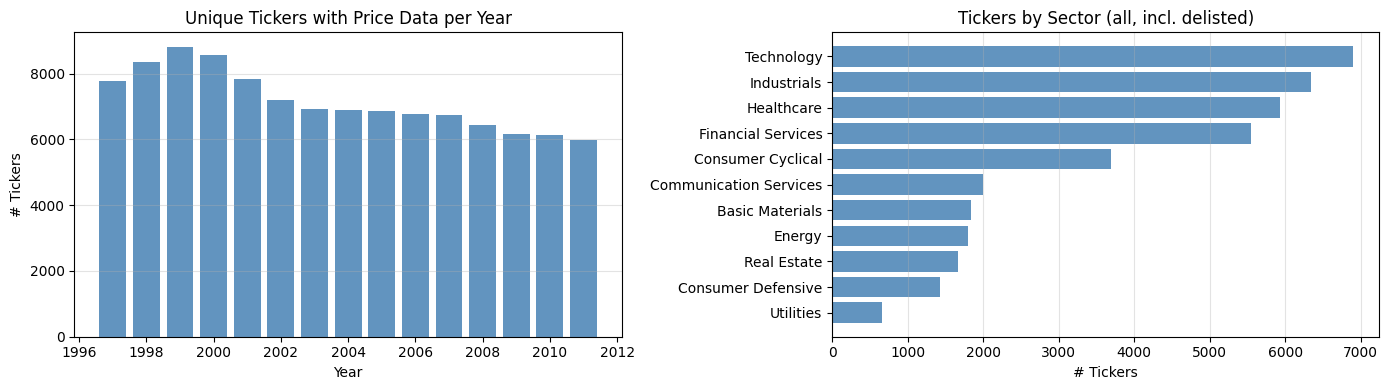


Missing % per year for key fundamentals:
      netinc  fcf  revenue  marketcap
year                                 
2002     1.3  1.8      1.3        5.4
2003     1.4  2.0      1.4        4.1
2004     1.8  2.4      1.7        3.6
2005     2.0  2.9      2.0        3.6
2006     2.1  2.9      2.1        3.5
2007     2.1  3.0      2.1        3.5
2008     1.7  2.5      1.7        3.0
2009     1.3  2.1      1.3        2.8
2010     2.0  3.1      2.0        3.0
2011     1.9  3.2      1.9        3.2


In [3]:
# Tickers active per year
prices["year"] = prices["date"].dt.year
tickers_per_year = prices.groupby("year")["ticker"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(tickers_per_year.index, tickers_per_year.values, color="steelblue", alpha=0.85)
axes[0].set_title("Unique Tickers with Price Data per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("# Tickers")
axes[0].grid(axis="y", alpha=0.35)

# Sector breakdown
sector_counts = tickers_meta["sector"].value_counts().head(12)
axes[1].barh(sector_counts.index[::-1], sector_counts.values[::-1], color="steelblue", alpha=0.85)
axes[1].set_title("Tickers by Sector (all, incl. delisted)")
axes[1].set_xlabel("# Tickers")
axes[1].grid(axis="x", alpha=0.35)

plt.tight_layout()
plt.show()

# Missing fundamentals rate per year
sf1_arq["year"] = sf1_arq["datekey"].dt.year
missing_rate = sf1_arq.groupby("year")[["netinc", "fcf", "revenue", "marketcap"]].apply(
    lambda g: g.isna().mean() * 100
).round(1)
print("\nMissing % per year for key fundamentals:")
print(missing_rate.tail(10).to_string())

## 2. Price Stats Over Time

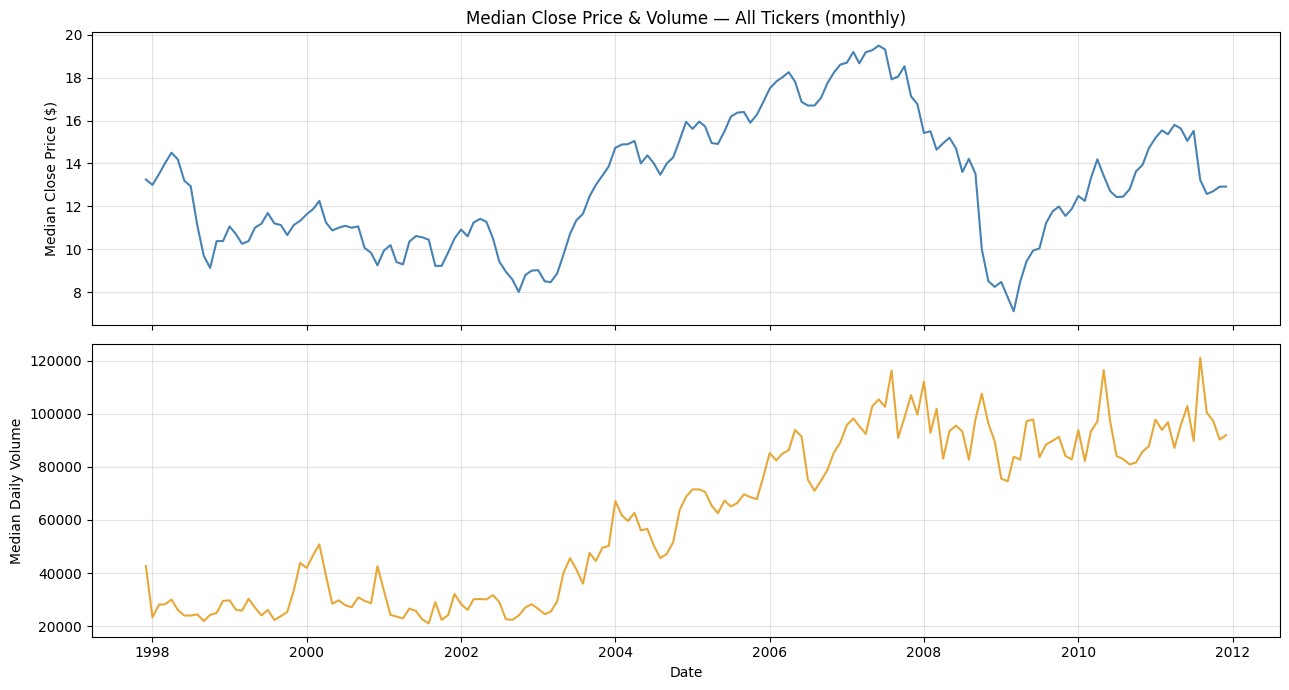

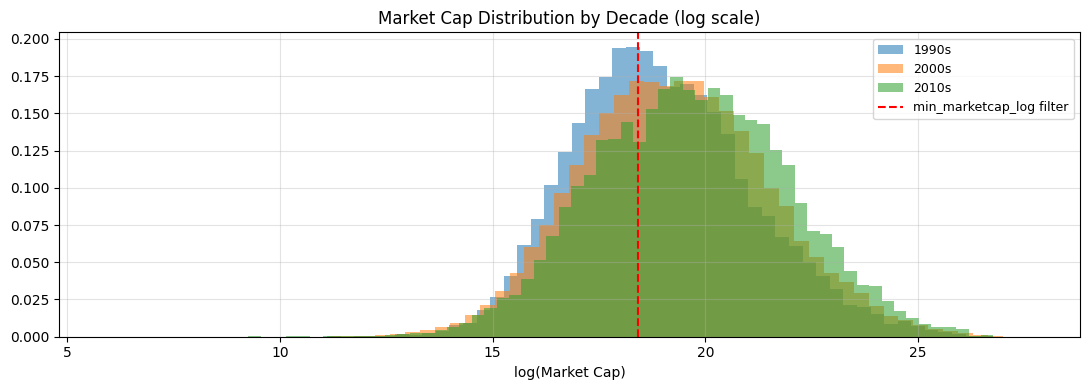

In [4]:
prices_monthly = prices.copy()
prices_monthly["month"] = prices_monthly["date"].dt.to_period("M").dt.to_timestamp()
monthly_stats = prices_monthly.groupby("month").agg(
    median_close=("close", "median"),
    median_volume=("volume", "median"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(monthly_stats["month"], monthly_stats["median_close"], linewidth=1.5, color="steelblue")
axes[0].set_ylabel("Median Close Price ($)")
axes[0].set_title("Median Close Price & Volume — All Tickers (monthly)")
axes[0].grid(alpha=0.35)

axes[1].plot(monthly_stats["month"], monthly_stats["median_volume"], linewidth=1.5, color="#E8A838")
axes[1].set_ylabel("Median Daily Volume")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.35)

plt.tight_layout()
plt.show()

# Market cap distribution histogram by decade
mc = sf1_arq.dropna(subset=["marketcap"])
mc = mc[mc["marketcap"] > 0].copy()
mc["log_mc"] = np.log(mc["marketcap"])
mc["decade"] = (mc["year"] // 10 * 10).astype(str) + "s"

fig, ax = plt.subplots(figsize=(11, 4))
for decade, grp in mc.groupby("decade"):
    ax.hist(grp["log_mc"], bins=60, alpha=0.55, label=decade, density=True)
ax.axvline(src.config.MODEL_SETTINGS["minimum_marketcap_log"], color="red",
            lw=1.5, ls="--", label="min_marketcap_log filter")
ax.set_xlabel("log(Market Cap)")
ax.set_title("Market Cap Distribution by Decade (log scale)")
ax.legend(fontsize=9)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

## 3. Fundamental Ratios Over Time

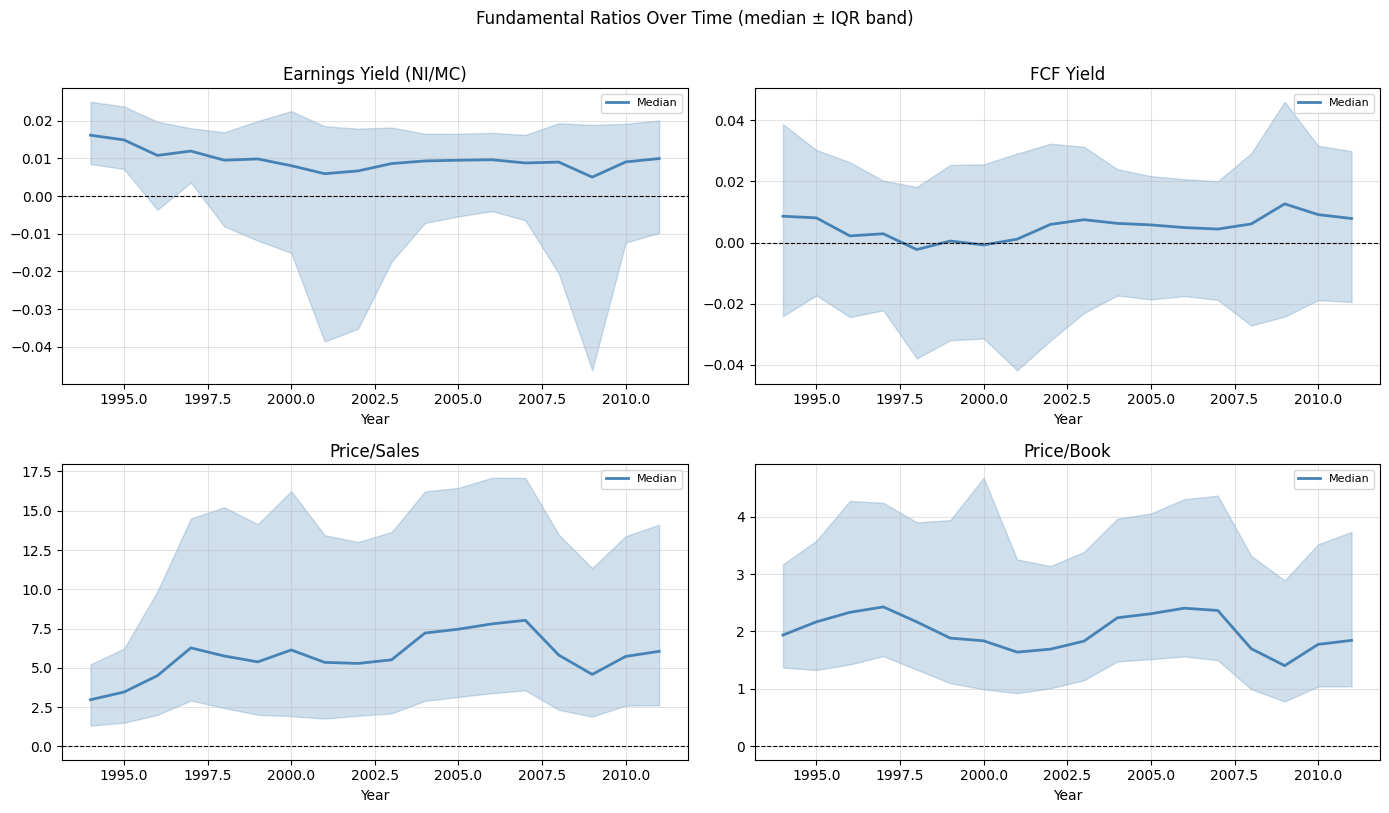

In [5]:
ratios = sf1_arq.dropna(subset=["marketcap", "netinc", "fcf", "revenue", "equity"]).copy()
ratios = ratios[ratios["marketcap"] > 0].copy()
ratios["ep"]   = ratios["netinc"]  / ratios["marketcap"]  # earnings yield
ratios["fcfp"] = ratios["fcf"]     / ratios["marketcap"]  # FCF yield
ratios["ps"]   = ratios["marketcap"] / ratios["revenue"].clip(lower=1)  # P/S
ratios["pb"]   = ratios["marketcap"] / ratios["equity"].clip(lower=1)  # P/B

ratio_cols = {"ep": "Earnings Yield (NI/MC)", "fcfp": "FCF Yield",
               "ps": "Price/Sales", "pb": "Price/Book"}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, title) in zip(axes, ratio_cols.items()):
    med = ratios.groupby("year")[col].median()
    q25 = ratios.groupby("year")[col].quantile(0.25)
    q75 = ratios.groupby("year")[col].quantile(0.75)
    ax.fill_between(med.index, q25, q75, alpha=0.25, color="steelblue")
    ax.plot(med.index, med, linewidth=2, color="steelblue", label="Median")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(alpha=0.35)
    ax.legend(fontsize=8)

plt.suptitle("Fundamental Ratios Over Time (median ± IQR band)", y=1.01)
plt.tight_layout()
plt.show()

## 4. Sector Comparison

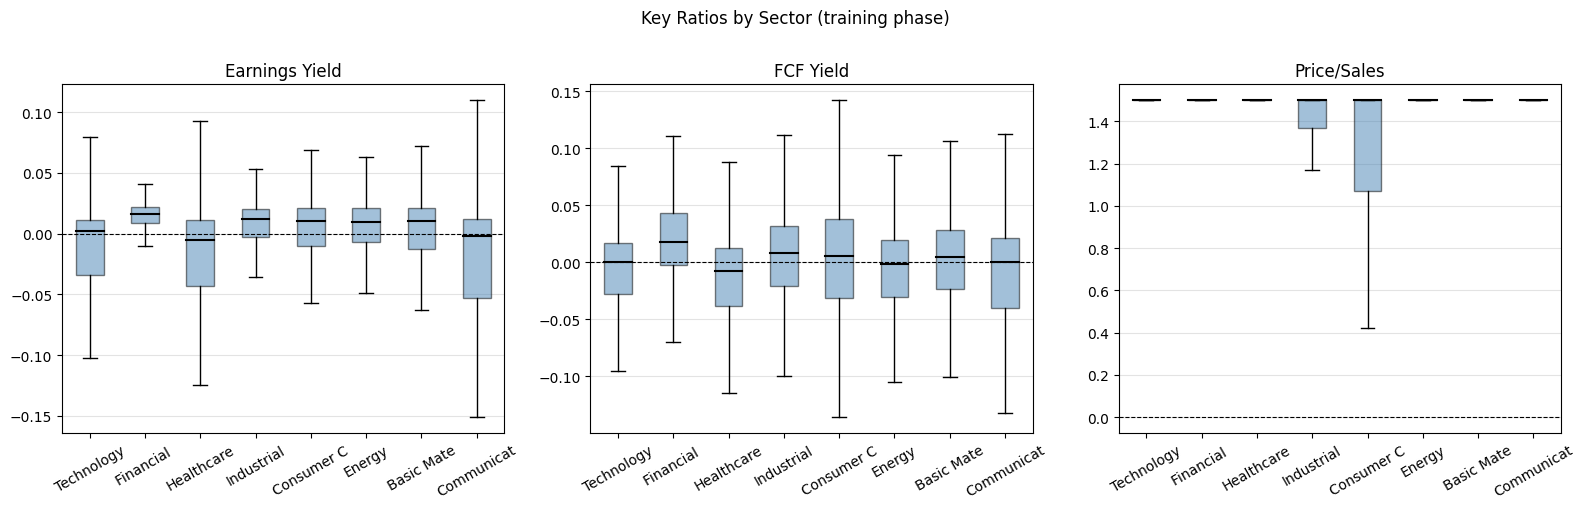

In [6]:
sf1_with_sector = sf1_arq.merge(tickers_meta[["ticker", "sector"]], on="ticker", how="left")
sf1_with_sector = sf1_with_sector.dropna(subset=["sector", "marketcap", "netinc", "fcf", "revenue"]).copy()
sf1_with_sector = sf1_with_sector[sf1_with_sector["marketcap"] > 0].copy()
sf1_with_sector["ep"]   = sf1_with_sector["netinc"]  / sf1_with_sector["marketcap"]
sf1_with_sector["fcfp"] = sf1_with_sector["fcf"]     / sf1_with_sector["marketcap"]
sf1_with_sector["ps"]   = sf1_with_sector["marketcap"] / sf1_with_sector["revenue"].clip(lower=1)

top_sectors = sf1_with_sector["sector"].value_counts().head(8).index.tolist()
sub = sf1_with_sector[sf1_with_sector["sector"].isin(top_sectors)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes, ["ep", "fcfp", "ps"],
                           ["Earnings Yield", "FCF Yield", "Price/Sales"]):
    data = [sub.loc[sub["sector"] == s, col].dropna().clip(-0.5, 1.5).values
            for s in top_sectors]
    ax.boxplot(data, labels=[s[:10] for s in top_sectors],
               patch_artist=True, showfliers=False,
               boxprops=dict(facecolor="steelblue", alpha=0.5),
               medianprops=dict(color="black", linewidth=1.5))
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.35)

plt.suptitle("Key Ratios by Sector (training phase)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Distribution Histograms (raw, before log-transform)

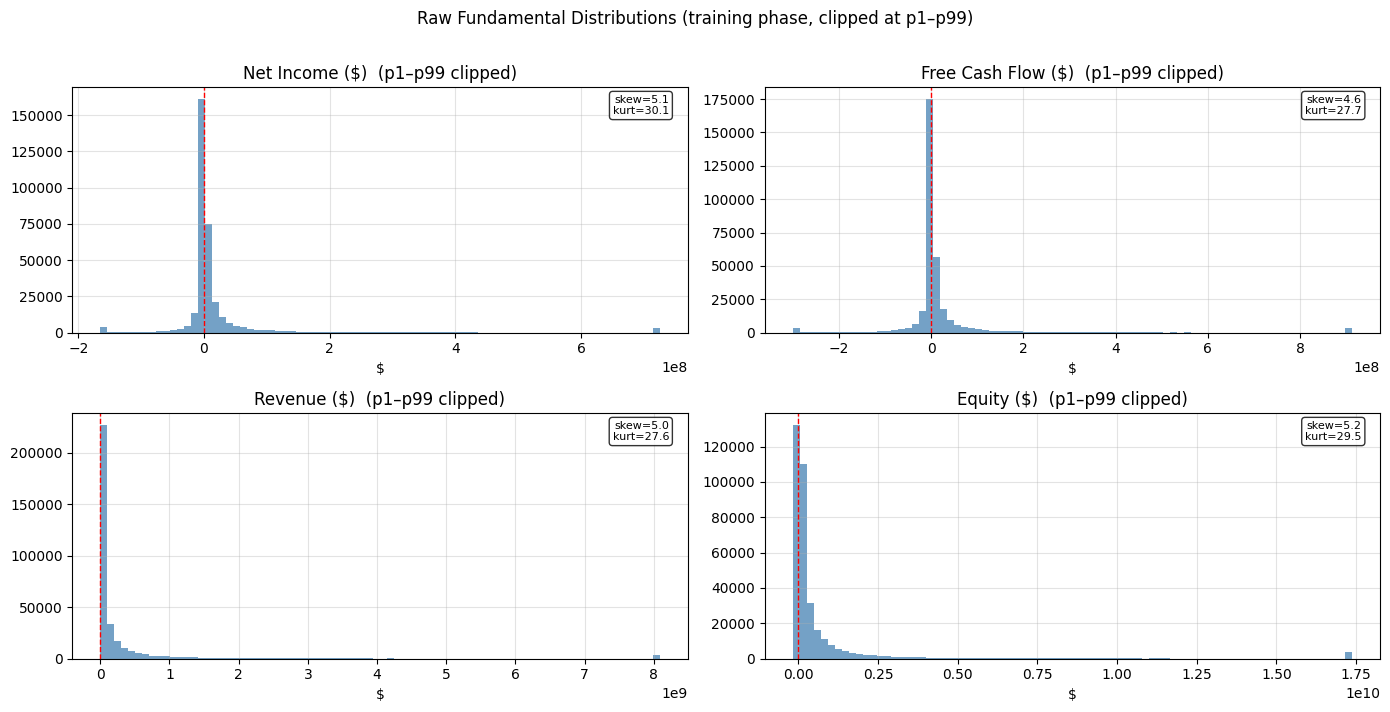

In [7]:
hist_cols = {"netinc": "Net Income ($)", "fcf": "Free Cash Flow ($)",
              "revenue": "Revenue ($)", "equity": "Equity ($)"}

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (col, title) in zip(axes, hist_cols.items()):
    vals = sf1_arq[col].dropna()
    clipped = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
    ax.hist(clipped, bins=80, color="steelblue", alpha=0.75, edgecolor="none")
    ax.axvline(0, color="red", lw=1, ls="--")
    ax.set_title(f"{title}  (p1–p99 clipped)")
    ax.set_xlabel("$")
    skew = float(clipped.skew())
    kurt = float(clipped.kurt())
    ax.text(0.97, 0.97, f"skew={skew:.1f}\nkurt={kurt:.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax.grid(alpha=0.35)

plt.suptitle("Raw Fundamental Distributions (training phase, clipped at p1–p99)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Momentum & Seasonality

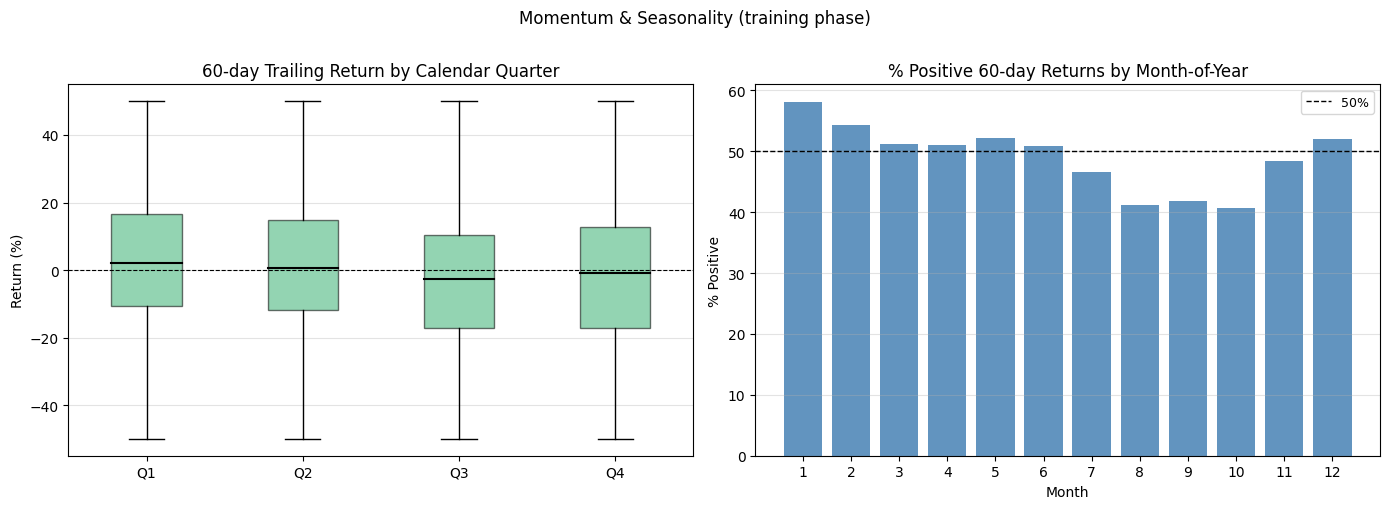

In [8]:
# Load processed daily prices to get the trailing 60-day return
_proc_prices_path = PROCESSED_DIR / "daily_prices_with_forward_prices.csv"
if _proc_prices_path.exists():
    proc_prices = pd.read_csv(_proc_prices_path, parse_dates=["date"],
                              usecols=["ticker", "date", "current_60_d_r"])
    proc_prices = proc_prices[proc_prices["date"] <= TRAIN_CUTOFF].dropna()
    proc_prices["quarter"] = proc_prices["date"].dt.quarter
    proc_prices["month"] = proc_prices["date"].dt.month
    proc_prices["return_pct"] = (proc_prices["current_60_d_r"] - 1) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Trailing return distribution by calendar quarter
    q_data = [proc_prices.loc[proc_prices["quarter"] == q, "return_pct"].clip(-50, 50).values
               for q in range(1, 5)]
    axes[0].boxplot(q_data, labels=["Q1", "Q2", "Q3", "Q4"],
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor="#3BB273", alpha=0.55),
                    medianprops=dict(color="black", linewidth=1.5))
    axes[0].axhline(0, color="black", lw=0.8, ls="--")
    axes[0].set_title("60-day Trailing Return by Calendar Quarter")
    axes[0].set_ylabel("Return (%)")
    axes[0].grid(axis="y", alpha=0.35)

    # % positive returns by month
    pct_pos = proc_prices.groupby("month")["return_pct"].apply(lambda x: (x > 0).mean() * 100)
    axes[1].bar(pct_pos.index, pct_pos.values, color="steelblue", alpha=0.85)
    axes[1].axhline(50, color="black", lw=1, ls="--", label="50%")
    axes[1].set_title("% Positive 60-day Returns by Month-of-Year")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("% Positive")
    axes[1].set_xticks(range(1, 13))
    axes[1].legend(fontsize=9)
    axes[1].grid(axis="y", alpha=0.35)

    plt.suptitle("Momentum & Seasonality (training phase)", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print(f"Processed prices not found at {_proc_prices_path}. Run build_processed_data.py first.")

## 7. Label Distribution (60-day forward return)

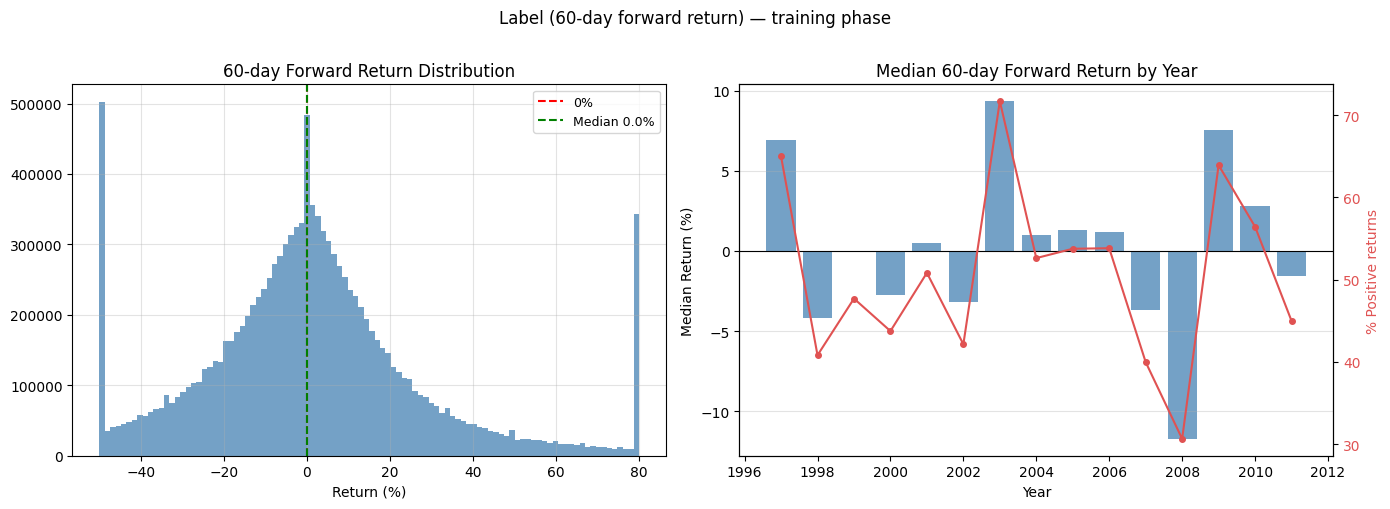

In [9]:
_proc_prices_path = PROCESSED_DIR / "daily_prices_with_forward_prices.csv"
if _proc_prices_path.exists():
    fwd = pd.read_csv(_proc_prices_path, parse_dates=["date"],
                      usecols=["ticker", "date", "close", "next_60_days_close"])
    fwd = fwd[fwd["date"] <= TRAIN_CUTOFF].dropna()
    fwd["label"] = (fwd["next_60_days_close"] / fwd["close"] - 1) * 100
    fwd["year"] = fwd["date"].dt.year

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall distribution
    clipped = fwd["label"].clip(-50, 80)
    axes[0].hist(clipped, bins=100, color="steelblue", alpha=0.75, edgecolor="none")
    axes[0].axvline(0, color="red", lw=1.5, ls="--", label="0%")
    axes[0].axvline(clipped.median(), color="green", lw=1.5, ls="--",
                     label=f"Median {clipped.median():.1f}%")
    axes[0].set_title("60-day Forward Return Distribution")
    axes[0].set_xlabel("Return (%)")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.35)

    # Median label by year
    med_by_year = fwd.groupby("year")["label"].median()
    pct_pos_year = fwd.groupby("year")["label"].apply(lambda x: (x > 0).mean() * 100)
    ax2 = axes[1]
    ax2.bar(med_by_year.index, med_by_year.values, color="steelblue", alpha=0.75, label="Median return")
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_title("Median 60-day Forward Return by Year")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Median Return (%)")
    ax2.grid(axis="y", alpha=0.35)
    ax2b = ax2.twinx()
    ax2b.plot(pct_pos_year.index, pct_pos_year.values, color="#E05252",
               marker="o", ms=4, linewidth=1.5, label="% Positive")
    ax2b.set_ylabel("% Positive returns", color="#E05252")
    ax2b.tick_params(axis="y", labelcolor="#E05252")

    plt.suptitle("Label (60-day forward return) — training phase", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print(f"Processed prices not found at {_proc_prices_path}. Run build_processed_data.py first.")